In [1]:
pip install numpy matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


Data type: float32
Min value: 0.3921226
Max value: 4999.8906

Data type: uint16


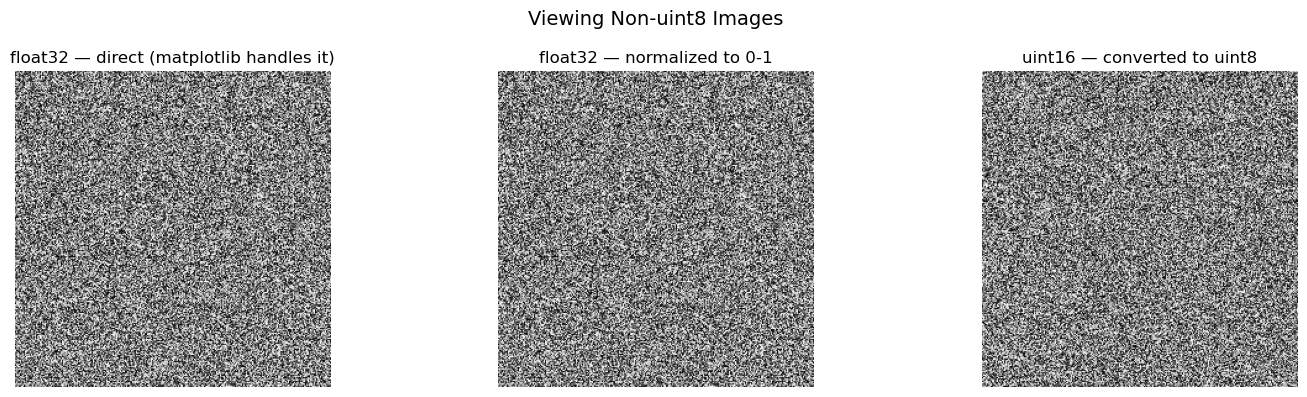

Output saved as q1_output.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ── 1. Simulate a non-uint8 image (float32) ──────────────────────────────────
# In real life, you'd load it like: img = np.load('image.npy') or tiff file
img_float32 = np.random.uniform(0, 5000, (256, 256)).astype(np.float32)
print("Data type:", img_float32.dtype)
print("Min value:", img_float32.min())
print("Max value:", img_float32.max())

# ── 2. Simulate a uint16 image ────────────────────────────────────────────────
img_uint16 = np.random.randint(0, 65535, (256, 256), dtype=np.uint16)
print("\nData type:", img_uint16.dtype)

# ── 3. Method 1: Normalize to 0-1 range (for float images) ───────────────────
def normalize_0_1(img):
    img = img.astype(np.float64)
    return (img - img.min()) / (img.max() - img.min())

# ── 4. Method 2: Convert to uint8 manually ───────────────────────────────────
def convert_to_uint8(img):
    img_norm = normalize_0_1(img)
    return (img_norm * 255).astype(np.uint8)

# ── 5. Method 3: Use matplotlib with cmap (handles non-uint8 automatically) ──
# matplotlib can display float images directly using colormaps

# ── 6. Display all versions ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(img_float32, cmap='gray')
axes[0].set_title('float32 — direct (matplotlib handles it)')
axes[0].axis('off')

axes[1].imshow(normalize_0_1(img_float32), cmap='gray')
axes[1].set_title('float32 — normalized to 0-1')
axes[1].axis('off')

axes[2].imshow(convert_to_uint8(img_uint16), cmap='gray')
axes[2].set_title('uint16 — converted to uint8')
axes[2].axis('off')

plt.suptitle('Viewing Non-uint8 Images', fontsize=14)
plt.tight_layout()
plt.savefig('q1_output.png', dpi=150)
plt.show()
print("Output saved as q1_output.png")

In [3]:
pip install Pillow piexif

Note: you may need to restart the kernel to use updated packages.


BASIC IMAGE INFORMATION
File Name     : my_pic.jpg
File Size     : 8811 bytes
Image Format  : JPEG
Image Mode    : RGB
Image Size    : (300, 168)

EXIF METADATA
No EXIF data found in this image.


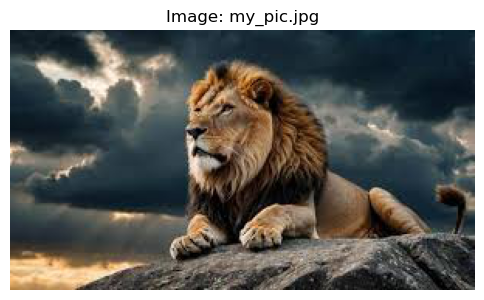


Output saved as q2_output.png


In [1]:
# ============================================================
# Q2 - Image Metadata (EXIF Data)
# ============================================================

from PIL import Image
from PIL.ExifTags import TAGS
import os
import matplotlib.pyplot as plt

image_path = "my_pic.jpg"

img = Image.open(image_path)

print("=" * 40)
print("BASIC IMAGE INFORMATION")
print("=" * 40)
print(f"File Name     : {os.path.basename(image_path)}")
print(f"File Size     : {os.path.getsize(image_path)} bytes")
print(f"Image Format  : {img.format}")
print(f"Image Mode    : {img.mode}")
print(f"Image Size    : {img.size}")

print("\n" + "=" * 40)
print("EXIF METADATA")
print("=" * 40)

exif_data = img._getexif()

if exif_data:
    for tag_id, value in exif_data.items():
        tag_name = TAGS.get(tag_id, tag_id)
        print(f"{tag_name:30}: {value}")
else:
    print("No EXIF data found in this image.")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Image: {os.path.basename(image_path)}")
plt.axis('off')
plt.savefig('q2_output.png', dpi=150)
plt.show()
print("\nOutput saved as q2_output.png")

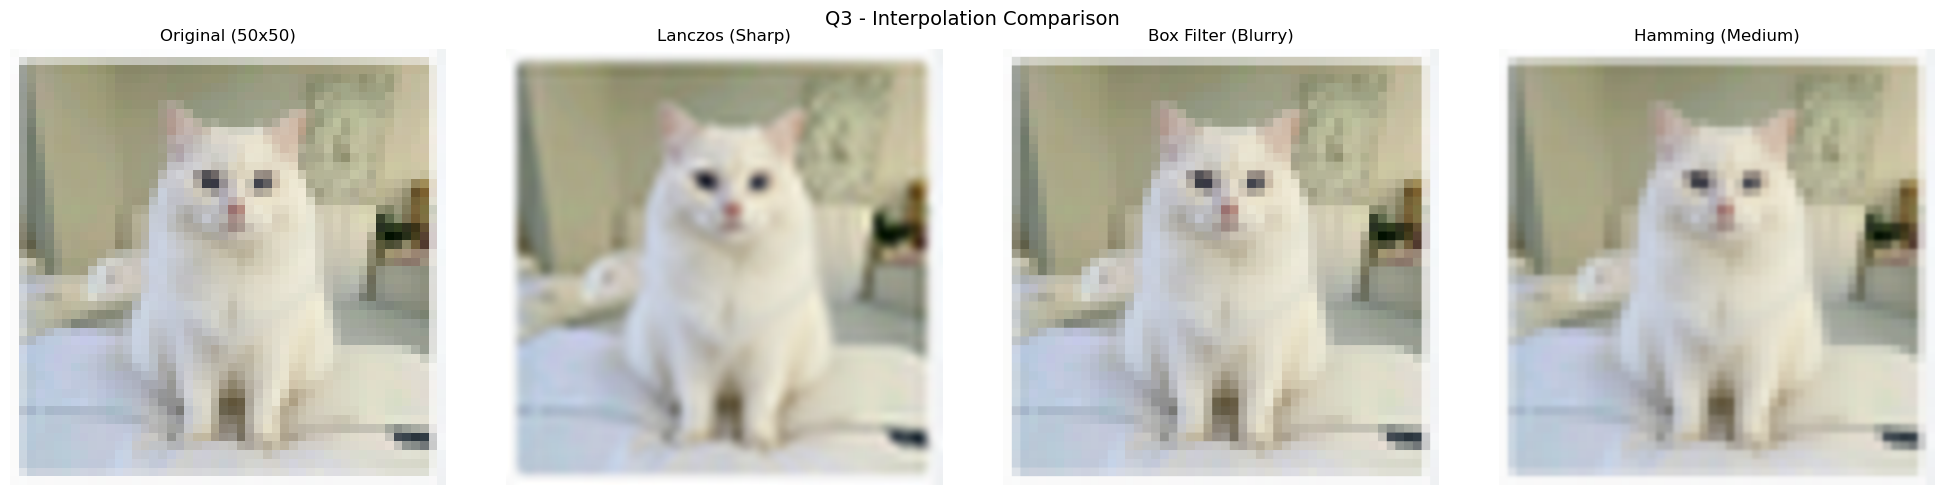

Done!


In [3]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("my_photo.jpg").convert("RGB")

# Pehle image ko bohot chota karo
small = img.resize((50, 50))

# Phir bada karo alag alag methods se
size_big = (400, 400)

img_lanczos = small.resize(size_big, Image.LANCZOS)
img_box = small.resize(size_big, Image.BOX)
img_hamming = small.resize(size_big, Image.HAMMING)

# Display
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(small)
axes[0].set_title('Original (50x50)')
axes[0].axis('off')

axes[1].imshow(img_lanczos)
axes[1].set_title('Lanczos (Sharp)')
axes[1].axis('off')

axes[2].imshow(img_box)
axes[2].set_title('Box Filter (Blurry)')
axes[2].axis('off')

axes[3].imshow(img_hamming)
axes[3].set_title('Hamming (Medium)')
axes[3].axis('off')

plt.suptitle('Q3 - Interpolation Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('q3_output.png', dpi=150)
plt.show()
print("Done!")

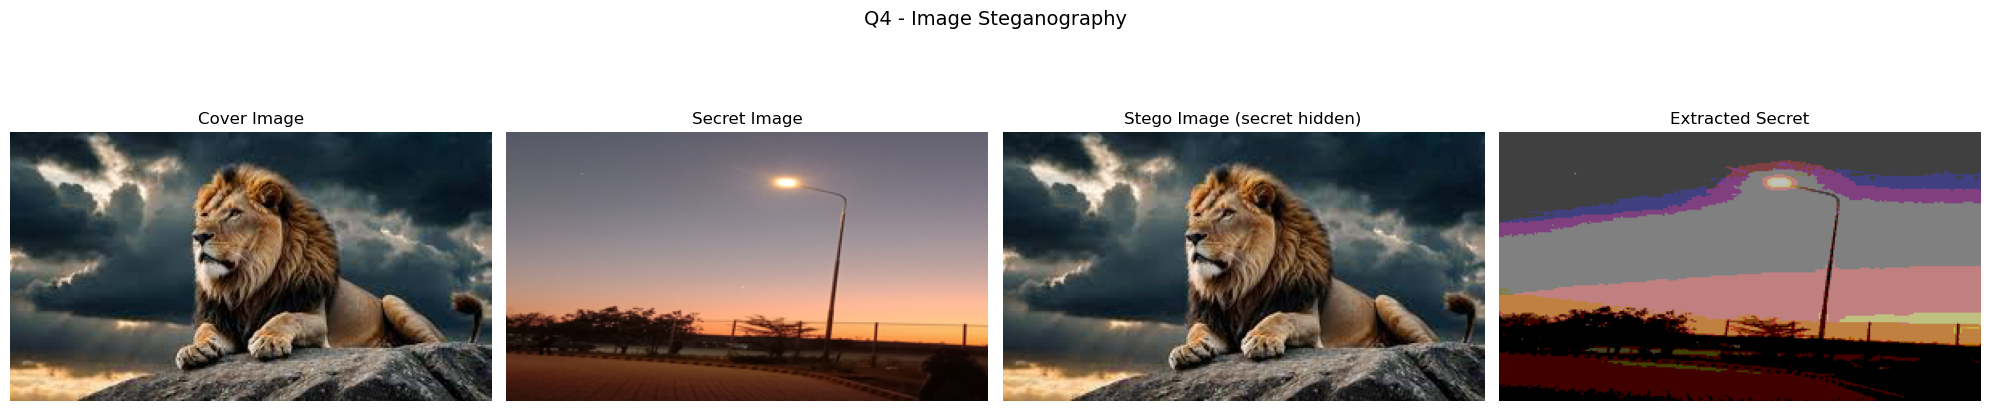

Done!


In [4]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

cover = Image.open("my_pic.jpg").convert("RGB")
secret = Image.open("secret.jpeg").convert("RGB")
secret = secret.resize(cover.size)

cover_arr = np.array(cover)
secret_arr = np.array(secret)

cover_high = cover_arr & 0xFC        
secret_high = secret_arr >> 6        
stego = cover_high | secret_high
stego_img = Image.fromarray(stego.astype(np.uint8))
stego_img.save("stego_image.png")

stego_arr = np.array(stego_img)
extracted = (stego_arr & 0x03) << 6
extracted_img = Image.fromarray(extracted.astype(np.uint8))
extracted_img.save("extracted_secret.png")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(cover)
axes[0].set_title('Cover Image')
axes[0].axis('off')
axes[1].imshow(secret)
axes[1].set_title('Secret Image')
axes[1].axis('off')
axes[2].imshow(stego_img)
axes[2].set_title('Stego Image (secret hidden)')
axes[2].axis('off')
axes[3].imshow(extracted_img)
axes[3].set_title('Extracted Secret')
axes[3].axis('off')

plt.suptitle('Q4 - Image Steganography', fontsize=14)
plt.tight_layout()
plt.savefig('q4_output.png', dpi=150)
plt.show()
print("Done!")

  IMAGE STEGANOGRAPHY APPLICATION — DIP Assignment 01
[StegoApp] Ready | LSBs: 2 | Capacity per 256x256: 49152 chars

[1] Generating demo images...

─────────────────────────────────────────────
  CAPACITY ANALYSIS
─────────────────────────────────────────────
  Image        : 256 × 256 pixels, 3 channels
  Total pixels : 65,536
  File size    : ~192 KB uncompressed
  1 LSB(s)      : 24,576 chars  (12% of image data used)
  2 LSB(s)      : 49,152 chars  (25% of image data used)
  4 LSB(s)      : 98,304 chars  (50% of image data used)
─────────────────────────────────────────────

[2] TEXT STEGANOGRAPHY
────────────────────────────────────────
  Hiding message (106 chars)...
  Original : This is a secret message hidden using LSB Steganography. Nobody can see this text by looking at the image!
  Extracted: This is a secret message hidden using LSB Steganography. Nobody can see this text by looking at the image!
  Match    : True

  Quality Report — Text Hiding
  PSNR     : 69.42 dB  (imp

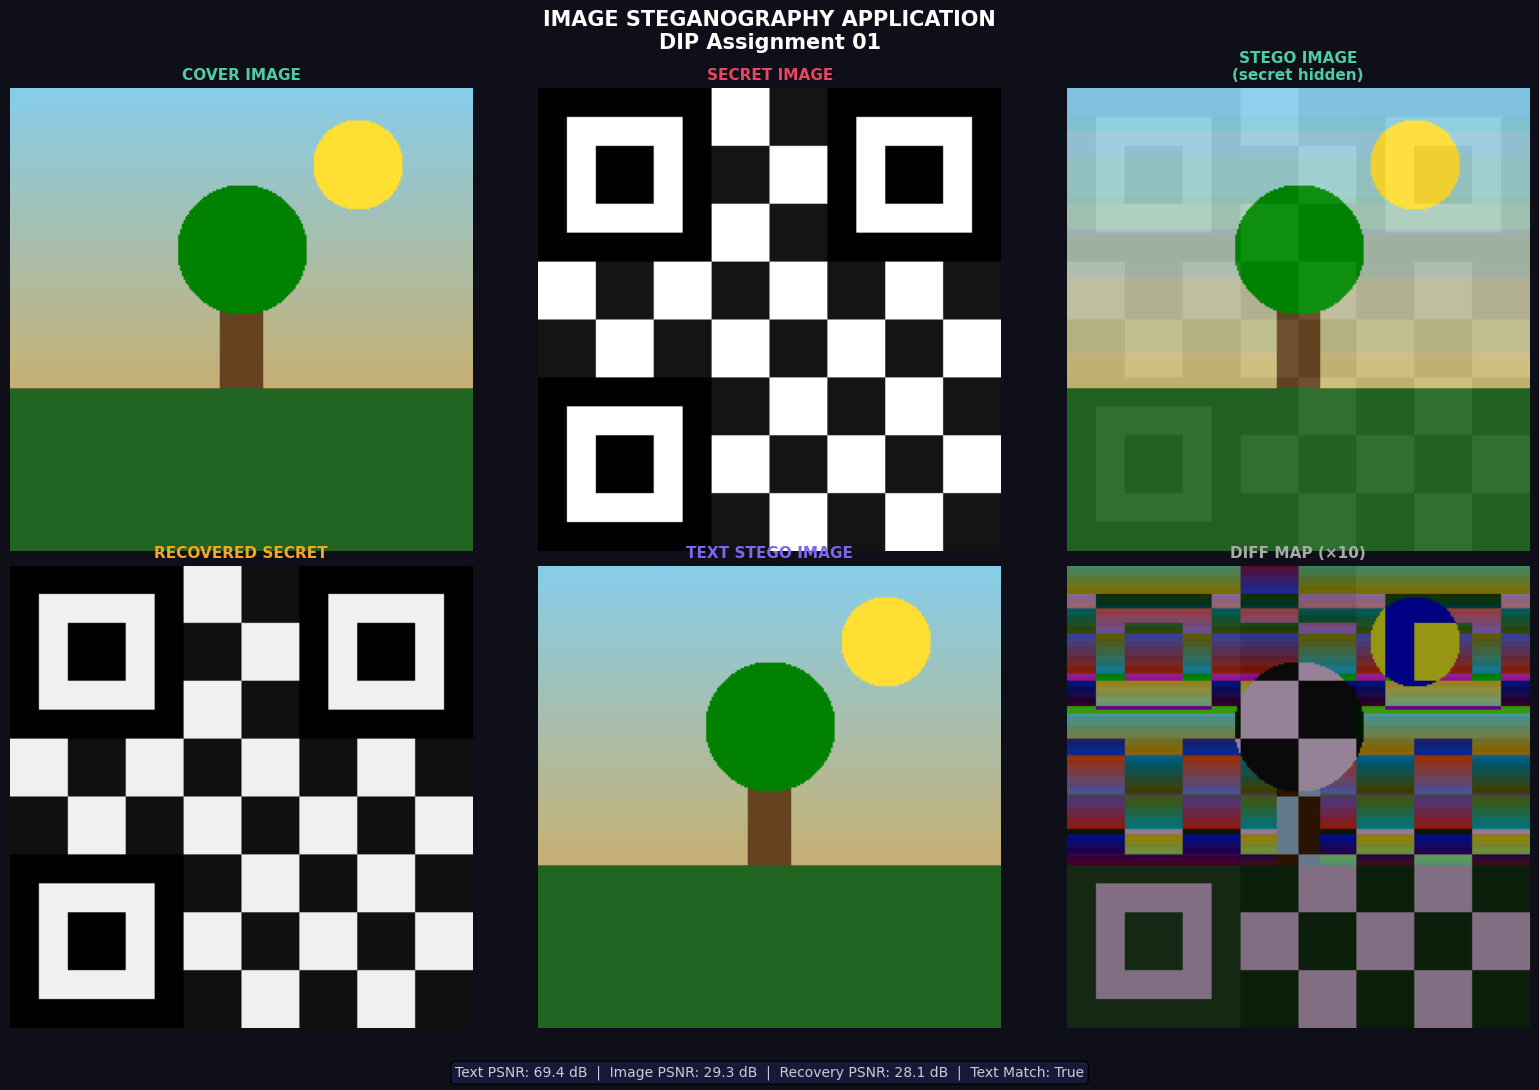


  ALL DONE! Check output images and steganography_output.png


In [13]:
"""
====================================================================
  IMAGE STEGANOGRAPHY APPLICATION
  Digital Image Processing — Assignment 01
  
  Author  : [Your Name]
  Reg No  : [Your Registration Number]
  GitHub  : https://github.com/YOUR_USERNAME/image-steganography-dip
====================================================================
  Features:
    - Hide TEXT inside any image using LSB technique
    - Extract hidden TEXT from stego image
    - Hide entire IMAGE inside another image
    - Extract hidden IMAGE from stego image
    - Capacity analysis
    - Quality metrics: PSNR and MSE
====================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import sys


# ════════════════════════════════════════════════════════════════════
#  CORE STEGANOGRAPHY CLASS
# ════════════════════════════════════════════════════════════════════

class ImageSteganography:
    """
    Full-featured Image Steganography application.
    Supports hiding both TEXT and IMAGES using LSB technique.
    """

    DELIMITER = '###END###'

    def __init__(self, bits=2):
        """
        Initialize with number of LSBs to use.
        bits=1 : most subtle, least capacity
        bits=2 : good balance (default)
        bits=4 : most capacity, slight visible difference
        """
        if bits not in [1, 2, 4]:
            raise ValueError('bits must be 1, 2, or 4')
        self.bits = bits
        print(f'[StegoApp] Ready | LSBs: {bits} | '
              f'Capacity per 256x256: {self.get_capacity(256,256)} chars')

    # ── Capacity ─────────────────────────────────────────────────────

    def get_capacity(self, width, height, channels=3):
        """Return max number of characters that can be hidden."""
        return (width * height * channels * self.bits) // 8

    def analyze_capacity(self, image_array):
        """Print detailed capacity analysis for an image."""
        h, w = image_array.shape[:2]
        c = image_array.shape[2] if image_array.ndim == 3 else 1
        print('\n' + '─' * 45)
        print('  CAPACITY ANALYSIS')
        print('─' * 45)
        print(f'  Image        : {w} × {h} pixels, {c} channels')
        print(f'  Total pixels : {w*h:,}')
        print(f'  File size    : ~{w*h*c // 1024} KB uncompressed')
        for b in [1, 2, 4]:
            chars = (w * h * c * b) // 8
            pct   = (b / 8) * 100
            print(f'  {b} LSB(s)      : {chars:,} chars  '
                  f'({pct:.0f}% of image data used)')
        print('─' * 45)

    # ── Text Steganography ───────────────────────────────────────────

    def _text_to_bits(self, text):
        bits = []
        for char in text + self.DELIMITER:
            byte = ord(char)
            for i in range(7, -1, -1):
                bits.append((byte >> i) & 1)
        return bits

    def _bits_to_text(self, bits):
        chars = []
        for i in range(0, len(bits) - 7, 8):
            byte = sum(bits[i+j] << (7-j) for j in range(8))
            chars.append(chr(byte))
        text = ''.join(chars)
        idx = text.find(self.DELIMITER)
        return text[:idx] if idx != -1 else text

    def hide_text(self, cover_array, secret_text):
        """
        Embed secret text into a cover image.
        
        Parameters:
            cover_array  : numpy array of cover image
            secret_text  : string to hide
        Returns:
            stego_array  : numpy array with hidden text
        """
        bits = self._text_to_bits(secret_text)
        h, w = cover_array.shape[:2]
        capacity_bits = w * h * (cover_array.shape[2] if cover_array.ndim==3 else 1) * self.bits

        if len(bits) > capacity_bits:
            raise ValueError(
                f'Text too long! Need {len(bits)} bits, '
                f'capacity is {capacity_bits} bits '
                f'({capacity_bits//8} chars).'
            )

        stego = cover_array.copy().flatten()
        mask  = ~((1 << self.bits) - 1) & 0xFF
        bit_idx = 0

        for i in range(len(stego)):
            if bit_idx >= len(bits):
                break
            chunk = 0
            for b in range(self.bits):
                if bit_idx + b < len(bits):
                    chunk |= bits[bit_idx + b] << (self.bits - 1 - b)
            stego[i] = (stego[i] & mask) | chunk
            bit_idx += self.bits

        return stego.reshape(cover_array.shape)

    def extract_text(self, stego_array):
        """
        Extract hidden text from a stego image.
        
        Parameters:
            stego_array : numpy array of stego image
        Returns:
            string : extracted secret text
        """
        flat = stego_array.flatten()
        mask = (1 << self.bits) - 1
        bits = []

        for val in flat:
            chunk = int(val) & mask
            for b in range(self.bits - 1, -1, -1):
                bits.append((chunk >> b) & 1)

        return self._bits_to_text(bits)

    # ── Image Steganography ──────────────────────────────────────────

    def hide_image(self, cover, secret, bits=4):
        """
        Embed a secret image inside a cover image.
        Both images must be the same size.
        
        Parameters:
            cover  : numpy array, cover (public) image
            secret : numpy array, secret image to hide
            bits   : number of LSBs to use (default 4)
        Returns:
            stego  : numpy array with hidden image
        """
        if cover.shape != secret.shape:
            raise ValueError(
                f'Cover {cover.shape} and secret {secret.shape} '
                'must be the same shape!'
            )
        mask_cover  = (0xFF << bits) & 0xFF
        mask_secret = (0xFF >> (8 - bits)) & 0xFF
        stego = (cover & mask_cover) | ((secret >> (8 - bits)) & mask_secret)
        return stego.astype(np.uint8)

    def extract_image(self, stego, bits=4):
        """
        Extract hidden image from a stego image.
        
        Parameters:
            stego : numpy array, stego image
            bits  : number of LSBs that were used during hiding
        Returns:
            recovered : numpy array, recovered secret image
        """
        mask = (1 << bits) - 1
        recovered = (stego & mask) << (8 - bits)
        return recovered.astype(np.uint8)

    # ── Quality Metrics ──────────────────────────────────────────────

    def psnr(self, original, compared):
        """Peak Signal-to-Noise Ratio. Higher = better quality."""
        mse_val = self.mse(original, compared)
        if mse_val == 0:
            return float('inf')
        return 20 * np.log10(255.0 / np.sqrt(mse_val))

    def mse(self, a, b):
        """Mean Squared Error. Lower = better quality."""
        return float(np.mean((a.astype(np.float64) - b.astype(np.float64))**2))

    def quality_report(self, cover, stego, label=''):
        """Print quality metrics comparing original and stego."""
        p = self.psnr(cover, stego)
        m = self.mse(cover, stego)
        diff_max = int(np.abs(cover.astype(int) - stego.astype(int)).max())
        print(f'\n  Quality Report {label}')
        print(f'  PSNR     : {p:.2f} dB  '
              f'({"imperceptible" if p>30 else "slight difference"})')
        print(f'  MSE      : {m:.4f}')
        print(f'  Max diff : {diff_max} (out of 255)')


# ════════════════════════════════════════════════════════════════════
#  IMAGE GENERATORS (for demo)
# ════════════════════════════════════════════════════════════════════

def generate_cover_image(size=256):
    """Generate a nature scene cover image."""
    img = np.zeros((size, size, 3), dtype=np.uint8)
    # Sky gradient
    for y in range(int(size * 0.65)):
        t = y / (size * 0.65)
        img[y, :] = [
            int(135 + 65 * t),
            int(206 - 30 * t),
            int(235 - 120 * t)
        ]
    # Ground
    img[int(size*0.65):, :] = [34, 100, 34]
    # Sun
    cy, cx, r = size//6, int(size*0.75), size//10
    for y in range(size):
        for x in range(size):
            if (y - cy)**2 + (x - cx)**2 < r**2:
                img[y, x] = [255, 223, 50]
    # Tree trunk
    tw = size // 20
    img[int(size*0.45):int(size*0.65),
        size//2-tw:size//2+tw] = [101, 67, 33]
    # Tree top
    for y in range(size):
        for x in range(size):
            if (y - int(size*0.35))**2 + (x - size//2)**2 < (size//7)**2:
                img[y, x] = [0, 130, 0]
    return img


def generate_secret_image(size=256):
    """Generate a QR-code-like secret image."""
    img = np.ones((size, size, 3), dtype=np.uint8) * 255
    cell = size // 8
    for i in range(8):
        for j in range(8):
            if (i + j) % 2 == 0:
                img[i*cell:(i+1)*cell, j*cell:(j+1)*cell] = [20, 20, 20]
    # Finder squares
    for (r, c) in [(0, 0), (0, size-cell*3), (size-cell*3, 0)]:
        img[r:r+cell*3, c:c+cell*3] = [0, 0, 0]
        img[r+cell//2:r+cell*3-cell//2,
            c+cell//2:c+cell*3-cell//2] = [255, 255, 255]
        img[r+cell:r+cell*2, c+cell:c+cell*2] = [0, 0, 0]
    return img


# ════════════════════════════════════════════════════════════════════
#  MAIN DEMONSTRATION
# ════════════════════════════════════════════════════════════════════

def main():
    print('=' * 60)
    print('  IMAGE STEGANOGRAPHY APPLICATION — DIP Assignment 01')
    print('=' * 60)

    # Initialize app
    app = ImageSteganography(bits=2)

    # Generate demo images
    print('\n[1] Generating demo images...')
    cover  = generate_cover_image(256)
    secret = generate_secret_image(256)
    app.analyze_capacity(cover)

    # ── TEXT STEGANOGRAPHY ────────────────────────────────────────
    print('\n[2] TEXT STEGANOGRAPHY')
    print('─' * 40)
    message = (
        'This is a secret message hidden using LSB Steganography. '
        'Nobody can see this text by looking at the image!'
    )
    print(f'  Hiding message ({len(message)} chars)...')
    stego_text = app.hide_text(cover, message)
    extracted  = app.extract_text(stego_text)

    print(f'  Original : {message}')
    print(f'  Extracted: {extracted}')
    print(f'  Match    : {message == extracted}')
    app.quality_report(cover, stego_text, '— Text Hiding')

    # ── IMAGE STEGANOGRAPHY ───────────────────────────────────────
    print('\n[3] IMAGE STEGANOGRAPHY')
    print('─' * 40)
    print('  Hiding secret image inside cover image (4 LSBs)...')
    stego_img  = app.hide_image(cover, secret, bits=4)
    recovered  = app.extract_image(stego_img, bits=4)

    app.quality_report(cover,  stego_img, '— Cover vs Stego')
    app.quality_report(secret, recovered, '— Secret vs Recovered')

    # ── SAVE OUTPUTS ─────────────────────────────────────────────
    print('\n[4] Saving output images...')
    output_files = {
        'cover_image.png'    : cover,
        'secret_image.png'   : secret,
        'stego_text.png'     : stego_text,
        'stego_image.png'    : stego_img,
        'recovered_secret.png': recovered,
    }
    for fname, arr in output_files.items():
        Image.fromarray(arr.astype(np.uint8)).save(fname)
        print(f'  Saved: {fname}')

    # ── VISUALIZATION ─────────────────────────────────────────────
    print('\n[5] Generating visualization...')
    fig, axes = plt.subplots(2, 3, figsize=(16, 11))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle(
        'IMAGE STEGANOGRAPHY APPLICATION\nDIP Assignment 01',
        fontsize=15, fontweight='bold', color='white'
    )

    display = [
        (cover,     'COVER IMAGE',          '#4ecca3'),
        (secret,    'SECRET IMAGE',         '#e94560'),
        (stego_img, 'STEGO IMAGE\n(secret hidden)', '#4ecca3'),
        (recovered, 'RECOVERED SECRET',     '#f5a623'),
        (stego_text,'TEXT STEGO IMAGE',     '#7b68ee'),
        (np.clip(np.abs(cover.astype(int)-stego_img.astype(int))*10,
                 0,255).astype(np.uint8),
                    'DIFF MAP (×10)',       '#aaaaaa'),
    ]

    for ax, (img, title, color) in zip(axes.flat, display):
        ax.imshow(img)
        ax.set_title(title, color=color, fontweight='bold', fontsize=11)
        ax.axis('off')
        ax.set_facecolor('#0f0f1a')

    metrics = (
        f'Text PSNR: {app.psnr(cover, stego_text):.1f} dB  |  '
        f'Image PSNR: {app.psnr(cover, stego_img):.1f} dB  |  '
        f'Recovery PSNR: {app.psnr(secret, recovered):.1f} dB  |  '
        f'Text Match: {message == extracted}'
    )
    fig.text(0.5, 0.01, metrics, ha='center', fontsize=10,
             color='#cccccc',
             bbox=dict(boxstyle='round', facecolor='#1a1a3e', alpha=0.9))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig('steganography_output.png', dpi=150,
                bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()

    print('\n' + '=' * 60)
    print('  ALL DONE! Check output images and steganography_output.png')
    print('=' * 60)


if __name__ == '__main__':
    main()

## Handwritten Notes - Q1 to Q4
[Click here to view notes](handwritten_notes.pdf)

## Q5 - GitHub Repository

**GitHub Link:**
https://github.com/faiza300/Image-Steganography-DIP

**Description:**
Image Steganography Application built using Python.
Hides one image inside another using LSB technique.

**Owner:** faiza300